# 04a — Week 4 setup & data prep verification

**Goal:** make sure the deep-learning stack on this machine is ready before we
spend an evening fine-tuning BiLSTM / PhoBERT models that fall over halfway
through training because of a missing CUDA toolkit or a 4-dim/300-dim
embedding mismatch.

Parts:

1. **A — Environment verify**: CUDA, GPU, HuggingFace, reproducibility seed.
2. **B — Data loading**: cleaned CSVs from Week 2 (auto-regen if missing).
3. **C — Vocab + embeddings**: build word vocabulary, download PhoW2V, build
   embedding matrix with coverage report.
4. **D — DataLoader smoke test**: one batch through `ViHSDDataset` in both
   `'bilstm'` and `'phobert'` modes.

All artefacts go under `models/dl/`. Random seed is fixed at **42** end-to-end.

In [1]:
# Auto-reload edited .py files (so editing src/*.py doesn't need a kernel restart).
%load_ext autoreload
%autoreload 2

# Drop any stale `src.*` modules cached from earlier in this kernel,
# so the next `from src...` import really hits disk.
import sys as _sys
for _k in [k for k in _sys.modules if k == 'src' or k.startswith('src.')]:
    del _sys.modules[_k]

# ── Common imports & project root ────────────────────────────────────────
import os, sys, time, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from configs.config import PATHS, COLUMNS, LABEL_MAP, DEEP_LEARNING_CONFIG, PHOBERT_CONFIG
from src.utils import set_seed, Timer

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

# Artefact directories for this week.
DL_DIR        = ROOT / "models" / "dl"
EMBED_DIR     = ROOT / "models" / "embeddings"
PROCESSED_DIR = ROOT / "data" / "processed"
for d in (DL_DIR, EMBED_DIR, PROCESSED_DIR):
    d.mkdir(parents=True, exist_ok=True)

TEXT, LABEL = COLUMNS["text"], COLUMNS["label"]
print(f"Project root  : {ROOT}")
print(f"Seed          : {RANDOM_STATE}")
print(f"DL artefacts  : {DL_DIR}")
print(f"Embeddings    : {EMBED_DIR}")

Project root  : d:\Graduation Project
Seed          : 42
DL artefacts  : d:\Graduation Project\models\dl
Embeddings    : d:\Graduation Project\models\embeddings


## Part A — Environment verification

In [2]:
# A1. CUDA & GPU sanity check ───────────────────────────────────────────
import torch

print(f"torch         : {torch.__version__}")
print(f"torch.cuda    : {torch.version.cuda}")
print(f"is_available  : {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    msg = (
        "\n✗ CUDA is NOT available — STOPPING.\n"
        "Install steps:\n"
        "  1) Verify NVIDIA driver:   nvidia-smi\n"
        "  2) Install CUDA-enabled PyTorch matching your driver, e.g.:\n"
        "       pip install torch --index-url https://download.pytorch.org/whl/cu121\n"
        "     (or cu118 / cu124 depending on driver — see https://pytorch.org)\n"
        "  3) Restart this kernel and re-run this cell.\n"
    )
    raise RuntimeError(msg)

idx = torch.cuda.current_device()
props = torch.cuda.get_device_properties(idx)
vram_gb = props.total_memory / 1024**3
print(f"GPU           : {props.name}")
print(f"VRAM total    : {vram_gb:.2f} GB")
print(f"Compute cap.  : {props.major}.{props.minor}")
print(f"Device index  : {idx} / {torch.cuda.device_count()}")

# RTX 3060 sanity: desktop = 12 GB, mobile = 6 GB. Calibrate batch advice to VRAM.
if vram_gb < 4.0:
    print(f"⚠ Only {vram_gb:.1f} GB VRAM — PhoBERT may not fit; expect frequent OOM.")
elif vram_gb < 8.0:
    print(f"ℹ {vram_gb:.1f} GB VRAM (laptop tier). Recommended PhoBERT settings:")
    print( "    batch_size=8, gradient_accumulation_steps=2  (eff. batch=16)")
    print( "    enable AMP (torch.cuda.amp.autocast / bf16) to halve activations.")
else:
    print(f"✓ {vram_gb:.1f} GB VRAM is comfortable for PhoBERT batch_size=16.")

torch         : 2.6.0+cu124
torch.cuda    : 12.4
is_available  : True
GPU           : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM total    : 6.00 GB
Compute cap.  : 8.6
Device index  : 0 / 1
ℹ 6.0 GB VRAM (laptop tier). Recommended PhoBERT settings:
    batch_size=8, gradient_accumulation_steps=2  (eff. batch=16)
    enable AMP (torch.cuda.amp.autocast / bf16) to halve activations.


In [3]:
# A2. GPU compute smoke test (1000×1000 matmul) ─────────────────────────
import torch, time

# Warm-up (first GPU op pays a one-time context-init cost).
_ = torch.randn(8, 8, device="cuda") @ torch.randn(8, 8, device="cuda")
torch.cuda.synchronize()

x = torch.randn(1000, 1000, device="cuda")
t0 = time.perf_counter()
y = x @ x.T
torch.cuda.synchronize()
dt_ms = (time.perf_counter() - t0) * 1000

print(f"1000×1000 matmul  : {dt_ms:.2f} ms")
print(f"output dtype/dev  : {y.dtype} on {y.device}")
print(f"output norm       : {y.norm().item():.4f}")

if dt_ms >= 100:
    print(f"⚠ Expected < 100 ms on a modern GPU; got {dt_ms:.1f} ms — check thermals / driver.")
else:
    print(f"✓ GPU compute OK ({dt_ms:.1f} ms)")

1000×1000 matmul  : 2.75 ms
output dtype/dev  : torch.float32 on cuda:0
output norm       : 44619.9219
✓ GPU compute OK (2.8 ms)


In [4]:
# A3. HuggingFace install + PhoBERT tokenizer verify ────────────────────
from transformers import AutoTokenizer

VERIFY_MODEL = "vinai/phobert-base"   # quick lightweight verify; v2 is used in training
print(f"Loading tokenizer: {VERIFY_MODEL} (downloads on first run, ~1-2 MB)")
with Timer("tokenizer-load"):
    tok = AutoTokenizer.from_pretrained(VERIFY_MODEL)

sample = "Hôm nay trời rất đẹp và tôi cảm thấy rất vui."
enc = tok(sample, return_tensors="pt")
tokens = tok.convert_ids_to_tokens(enc["input_ids"][0].tolist())

print(f"  tokenizer type : {type(tok).__name__}")
print(f"  vocab size     : {tok.vocab_size:,}")
print(f"  pad / unk / cls: {tok.pad_token_id} / {tok.unk_token_id} / {tok.cls_token_id}")
print(f"  sample text    : {sample!r}")
print(f"  → {len(tokens)} tokens:")
print(f"    {tokens}")

Loading tokenizer: vinai/phobert-base (downloads on first run, ~1-2 MB)


[tokenizer-load] 0:02 (1.96s)
  tokenizer type : PhobertTokenizer
  vocab size     : 64,000
  pad / unk / cls: 1 / 3 / 0
  sample text    : 'Hôm nay trời rất đẹp và tôi cảm thấy rất vui.'
  → 14 tokens:
    ['<s>', 'Hôm', 'nay', 'trời', 'rất', 'đẹp', 'và', 'tôi', 'cảm', 'thấy', 'rất', 'vu@@', 'i.', '</s>']


In [5]:
# A4. Reproducibility check ─────────────────────────────────────────────
# `set_seed` is the canonical entry point used by every training script;
# here we just confirm two consecutive calls produce identical random draws.
from src.utils import set_seed
import torch, numpy as np, random

def fingerprint() -> dict:
    return {
        "py":    random.random(),
        "np":    float(np.random.rand()),
        "torch": float(torch.rand(1).item()),
        "cuda":  float(torch.rand(1, device="cuda").item()),
    }

set_seed(42); a = fingerprint()
set_seed(42); b = fingerprint()
print("draw 1:", a)
print("draw 2:", b)
assert a == b, "Reproducibility broken — investigate before training."
print("✓ set_seed(42) is reproducible across all RNGs.")

draw 1: {'py': 0.6394267984578837, 'np': 0.3745401188473625, 'torch': 0.8822692632675171, 'cuda': 0.6129598617553711}
draw 2: {'py': 0.6394267984578837, 'np': 0.3745401188473625, 'torch': 0.8822692632675171, 'cuda': 0.6129598617553711}
✓ set_seed(42) is reproducible across all RNGs.


## Part B — Data loading

Re-uses the cleaned splits produced by `02_preprocessing`. The auto-regen
block below mirrors what `03b` does, so this notebook works on a fresh
clone too.

In [6]:
# B1. Load cleaned splits (auto-regen if missing) ───────────────────────
required_csvs = {split: PROCESSED_DIR / f"{split}_cleaned.csv"
                 for split in ("train", "dev", "test")}
missing = [p for p in required_csvs.values() if not p.exists()]

if missing:
    print(f"⚠ Missing cleaned CSVs: {[p.name for p in missing]}")
    print("→ Regenerating from data/raw/ (~2-3 min)...")
    from src.preprocess import VietnameseTextCleaner, batch_clean
    cleaner = VietnameseTextCleaner()
    for split, out in required_csvs.items():
        df = pd.read_csv(PATHS[f"raw_{split}"])
        df["cleaned"] = batch_clean(df[TEXT], cleaner=cleaner, desc=split)
        df[[TEXT, "cleaned", LABEL]].to_csv(out, index=False)
        print(f"  ✓ {out.name}: {len(df):,} rows")

train_df = pd.read_csv(required_csvs["train"])
dev_df   = pd.read_csv(required_csvs["dev"])
test_df  = pd.read_csv(required_csvs["test"])

# Force string dtype + drop NaN-as-empty
for df in (train_df, dev_df, test_df):
    df["cleaned"] = df["cleaned"].fillna("").astype(str)

print(f"train : {len(train_df):,}  |  label dist: {dict(train_df[LABEL].value_counts().sort_index())}")
print(f"dev   : {len(dev_df):,}    |  label dist: {dict(dev_df[LABEL].value_counts().sort_index())}")
print(f"test  : {len(test_df):,}   |  label dist: {dict(test_df[LABEL].value_counts().sort_index())}")
train_df.head(3)

train : 24,048  |  label dist: {0: np.int64(19886), 1: np.int64(1606), 2: np.int64(2556)}
dev   : 2,672    |  label dist: {0: np.int64(2190), 1: np.int64(212), 2: np.int64(270)}
test  : 6,680   |  label dist: {0: np.int64(5548), 1: np.int64(444), 2: np.int64(688)}


,free_text,cleaned,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,em được làm fan cứng luôn rồi nè reaction quá ...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,đúng là bọn mắt híp lò_xo thụt bên việt_nam ta...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,đậu văn_cường giờ giống thằng sida hơn à,0


## Part C — Vocabulary & pretrained embeddings

* Build a word-level vocabulary from `train_cleaned` only (never from
  dev/test — that would leak label-correlated tokens).
* Download a Vietnamese word-embedding file (PhoW2V 100d by default;
  fastText cc.vi.300 is offered as a heavier alternative).
* Build the `(vocab_size, dim)` embedding matrix and report coverage.

In [7]:
# C1. Build vocab from train_cleaned ────────────────────────────────────
from src.dataset_dl import Vocab

VOCAB_PATH = DL_DIR / "vocab.pkl"
MIN_FREQ   = 2
MAX_SIZE   = 20_000

with Timer("build-vocab"):
    vocab = Vocab.build_from_texts(train_df["cleaned"], min_freq=MIN_FREQ, max_size=MAX_SIZE)

print(f"  vocab size           : {len(vocab):,}  (cap {MAX_SIZE:,}, min_freq {MIN_FREQ})")
print(f"  unique words in train: {len(vocab.freqs):,}")
print(f"  specials             : {vocab.itos[:4]}")

print("\n  top 20 most-common tokens:")
for tok, c in vocab.freqs.most_common(20):
    print(f"    {tok:<20s} {c:>6,}")

vocab.save(VOCAB_PATH)
print(f"\n✓ saved → {VOCAB_PATH}")

[build-vocab] 0:00 (0.07s)
  vocab size           : 8,990  (cap 20,000, min_freq 2)
  unique words in train: 22,775
  specials             : ['<pad>', '<unk>', '<bos>', '<eos>']

  top 20 most-common tokens:
    không                 4,215
    là                    3,108
    có                    2,910
    anh                   2,642
    mà                    2,150
    cho                   2,068
    đi                    1,946
    thì                   1,917
    được                  1,783
    rồi                   1,771
    này                   1,757
    em                    1,620
    của                   1,522
    cái                   1,467
    vậy                   1,425
    gì                    1,423
    người                 1,421
    con                   1,405
    quá                   1,343
    nó                    1,335

✓ saved → d:\Graduation Project\models\dl\vocab.pkl


In [8]:
# C2. Choose & download a pretrained embedding file ─────────────────────
# Default: PhoW2V 300d (best for this project — same underthesea tokenisation
# as our cleaned text, same authorship as PhoBERT). The file must be placed
# manually because VinAI's public.vinai.io is offline and the canonical
# source is now Google Drive via the PhoW2V GitHub repo.
#
# To switch source: change EMBEDDING_CHOICE below. The pipeline is
# dim-agnostic — whatever file you point at, build_embedding_matrix will
# detect the dim and produce a matching matrix.
EMBEDDING_CHOICE = "phow2v_300d"

EMBEDDING_OPTIONS = {
    # PRIMARY — manual download required, ~4 GB, 300d
    "phow2v_300d": {
        "url":          None,                                            # manual only
        "path":         EMBED_DIR / "phow2v_300d.txt",
        "dim":          300,
        "download_doc": (
            "Manual download — VinAI's public.vinai.io is offline.\n"
            "  1. Open https://github.com/datquocnguyen/PhoW2V\n"
            "  2. In the README table, find the row 'word' / dim '300'\n"
            "  3. Click the Google Drive link and download "
                  "'word2vec_vi_words_300dims.txt' (~4 GB)\n"
            "  4. If you get a .zip, extract it. The file must be plain text.\n"
            f"  5. Move/rename it to: {EMBED_DIR / 'phow2v_300d.txt'}\n"
            "  6. Re-run this cell — it will skip download and just verify."
        ),
    },
    # Same source, smaller, 100d
    "phow2v_100d": {
        "url":          None,
        "path":         EMBED_DIR / "phow2v_100d.txt",
        "dim":          100,
        "download_doc": (
            "Manual download — see the 100d 'word' row at:\n"
            "  https://github.com/datquocnguyen/PhoW2V\n"
            f"Place the file at: {EMBED_DIR / 'phow2v_100d.txt'}"
        ),
    },
    # AUTO fallback — works without manual steps but lower coverage on our cleaned text
    "fasttext_cc_vi_300d": {
        "url":          "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.vec.gz",
        "path":         EMBED_DIR / "cc.vi.300.vec.gz",
        "dim":          300,
        "download_doc": "Auto-download from dl.fbaipublicfiles.com (~1.5 GB compressed).",
    },
}

choice = EMBEDDING_OPTIONS[EMBEDDING_CHOICE]
print(f"Choice : {EMBEDDING_CHOICE}  (dim={choice['dim']})")
print(f"Target : {choice['path']}")

if choice["path"].exists():
    size_mb = choice["path"].stat().st_size / 1024**2
    print(f"✓ already downloaded ({size_mb:,.1f} MB) — skipping.")
elif choice["url"] is None:
    raise FileNotFoundError(
        f"\n✗ {choice['path']} not found and this choice has no auto-download.\n\n"
        f"{choice['download_doc']}\n"
    )
else:
    import urllib.request
    print(f"⬇ downloading from {choice['url']}")
    print(f"  {choice['download_doc']}")
    t0 = time.perf_counter()

    def _reporthook(blocks, block_size, total_size):
        done = blocks * block_size
        pct  = 100 * done / total_size if total_size > 0 else 0
        if blocks % 200 == 0:
            print(f"    … {done/1024**2:>7.1f} MB ({pct:5.1f}%)")

    urllib.request.urlretrieve(choice["url"], choice["path"], _reporthook)
    dt = time.perf_counter() - t0
    print(f"✓ downloaded {choice['path'].stat().st_size/1024**2:,.1f} MB in {dt:.1f}s")

Choice : phow2v_300d  (dim=300)
Target : d:\Graduation Project\models\embeddings\phow2v_300d.txt
✓ already downloaded (5,548.1 MB) — skipping.


In [9]:
# C3. Build embedding matrix ────────────────────────────────────────────
from src.dataset_dl import build_embedding_matrix

EMBEDDING_MATRIX_PATH = DL_DIR / f"embedding_matrix_{EMBEDDING_CHOICE}.pt"

with Timer("build-embedding"):
    emb, stats = build_embedding_matrix(
        vocab             = vocab,
        embedding_path    = choice["path"],
        dim               = choice["dim"],
        unk_init_range    = 0.25,
        seed              = RANDOM_STATE,
        compound_fallback = True,        # average parts of "hôm_nay" if not direct
    )

print(f"  shape           : {tuple(emb.shape)}")
print(f"  dtype           : {emb.dtype}")
print(f"  direct hits     : {stats['found_direct']:,}  ({stats['found_direct']/stats['vocab_size']:.1%})")
print(f"  compound fallback: {stats['found_compound']:,}  (averaged parts)")
print(f"  total coverage  : {stats['found']:,} / {stats['vocab_size']:,}  ({stats['coverage']:.1%})")
print(f"  missing         : {stats['missing']:,}  (random-init in [-0.25, 0.25])")

# Realistic expectations:
#   PhoW2V (same underthesea tokenisation)         → 70-85% direct
#   fastText cc.vi (raw text) + compound fallback  → 50-70% combined
#   fastText cc.vi without fallback                → 25-35% direct
expected_floor = 0.70 if EMBEDDING_CHOICE.startswith("phow2v") else 0.50
if stats["coverage"] < expected_floor:
    print(f"⚠ Coverage {stats['coverage']:.1%} below the {expected_floor:.0%} floor for {EMBEDDING_CHOICE}.")
    print( "  → If using fastText: check that text was cleaned with underthesea (underscore-joined words).")
else:
    print(f"✓ coverage within expected band for {EMBEDDING_CHOICE}.")

torch.save({"embedding": emb, "stats": stats, "choice": EMBEDDING_CHOICE},
           EMBEDDING_MATRIX_PATH)
print(f"\n✓ saved → {EMBEDDING_MATRIX_PATH}")

  loaded phow2v_300d.txt in 9.1s  |  coverage 8,423/8,990 (93.7%) (+1,666 via compound fallback)  |  dim=300
[build-embedding] 0:09 (9.11s)
  shape           : (8990, 300)
  dtype           : torch.float32
  direct hits     : 6,756  (75.2%)
  compound fallback: 1,666  (averaged parts)
  total coverage  : 8,423 / 8,990  (93.7%)
  missing         : 567  (random-init in [-0.25, 0.25])
✓ coverage within expected band for phow2v_300d.

✓ saved → d:\Graduation Project\models\dl\embedding_matrix_phow2v_300d.pt


In [10]:
# C4. Class weights for the imbalanced 3-class loss ─────────────────────
from src.dataset_dl import get_class_weights

class_weights = get_class_weights(train_df[LABEL])
print("class weights (sklearn 'balanced'):")
for i, w in enumerate(class_weights.tolist()):
    print(f"  {i} = {LABEL_MAP[i]:<10s} → {w:.4f}")

torch.save(class_weights, DL_DIR / "class_weights.pt")
print(f"\n✓ saved → {DL_DIR / 'class_weights.pt'}")

class weights (sklearn 'balanced'):
  0 = CLEAN      → 0.4031
  1 = OFFENSIVE  → 4.9913
  2 = HATE       → 3.1362

✓ saved → d:\Graduation Project\models\dl\class_weights.pt


## Part D — `ViHSDDataset` + `DataLoader` smoke test

One batch through each mode. The shapes (and lack of exceptions) are the
deliverable here.

In [12]:
# D1. BiLSTM mode ───────────────────────────────────────────────────────
from torch.utils.data import DataLoader
from src.dataset_dl import ViHSDDataset, collate_fn_bilstm

BATCH_SIZE = DEEP_LEARNING_CONFIG["batch_size"]
MAX_LEN    = DEEP_LEARNING_CONFIG["max_len"]

train_ds_lstm = ViHSDDataset(
    texts     = train_df["cleaned"].tolist(),
    labels    = train_df[LABEL].tolist(),
    tokenizer = vocab,
    max_len   = MAX_LEN,
    mode      = "bilstm",
)
print(f"len(train_ds_lstm) = {len(train_ds_lstm):,}")
print(f"item[0] keys       = {list(train_ds_lstm[0].keys())}")
print(f"item[0] shapes     = " + str({k: tuple(v.shape) for k, v in train_ds_lstm[0].items()}))

loader = DataLoader(
    train_ds_lstm,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    collate_fn = collate_fn_bilstm,
    generator  = torch.Generator().manual_seed(RANDOM_STATE),
)
batch = next(iter(loader))
print("\nbatch shapes:")
for k, v in batch.items():
    print(f"  {k:<11s} {str(tuple(v.shape)):<14s} {v.dtype}")
print(f"  lengths[:8]  : {batch['lengths'][:8].tolist()}")
print(f"  labels[:8]   : {batch['labels'][:8].tolist()}")

len(train_ds_lstm) = 24,048
item[0] keys       = ['input_ids', 'length', 'label']
item[0] shapes     = {'input_ids': (19,), 'length': (), 'label': ()}

batch shapes:
  input_ids   (64, 50)       torch.int64
  lengths     (64,)          torch.int64
  labels      (64,)          torch.int64
  lengths[:8]  : [2, 26, 6, 1, 8, 2, 3, 10]
  labels[:8]   : [0, 0, 0, 0, 0, 0, 0, 2]


In [14]:
# D2. PhoBERT mode ──────────────────────────────────────────────────────
from src.dataset_dl import collate_fn_phobert

PHOBERT_NAME = PHOBERT_CONFIG["pretrained_model"]   # vinai/phobert-base-v2 by default
print(f"Loading tokenizer for training: {PHOBERT_NAME}")
with Timer("phobert-tokenizer-load"):
    phobert_tok = AutoTokenizer.from_pretrained(PHOBERT_NAME, use_fast=False)

train_ds_bert = ViHSDDataset(
    texts     = train_df["cleaned"].tolist(),
    labels    = train_df[LABEL].tolist(),
    tokenizer = phobert_tok,
    max_len   = PHOBERT_CONFIG["max_len"],
    mode      = "phobert",
)
print(f"len(train_ds_bert) = {len(train_ds_bert):,}")
print(f"item[0] shapes     = " + str({k: tuple(v.shape) for k, v in train_ds_bert[0].items()}))

loader_bert = DataLoader(
    train_ds_bert,
    batch_size = PHOBERT_CONFIG["batch_size"],
    shuffle    = True,
    collate_fn = collate_fn_phobert,
    generator  = torch.Generator().manual_seed(RANDOM_STATE),
)
batch_bert = next(iter(loader_bert))
print("\nbatch shapes:")
for k, v in batch_bert.items():
    print(f"  {k:<14s} {str(tuple(v.shape)):<14s} {v.dtype}")
print(f"  labels[:8]      : {batch_bert['labels'][:8].tolist()}")

Loading tokenizer for training: vinai/phobert-base-v2
[phobert-tokenizer-load] 0:02 (1.98s)
len(train_ds_bert) = 24,048
item[0] shapes     = {'input_ids': (256,), 'attention_mask': (256,), 'label': ()}

batch shapes:
  input_ids      (16, 256)      torch.int64
  attention_mask (16, 256)      torch.int64
  labels         (16,)          torch.int64
  labels[:8]      : [0, 0, 0, 0, 0, 0, 0, 2]


Part E — Pre-training verification (length, memory, sanity training)
Before spending hours on 04b (BiLSTM) and 04c (PhoBERT), three checks worth ~20 min that prevent the most common failure modes on a 6 GB laptop GPU plus an imbalanced 3-class ViHSD setup:

E1 — Sequence length distribution. Are there many 1-2 token samples (NaN-gradient risk on the BiLSTM)? Does max_len=256 waste compute, or is it actually needed?
E2 — PhoBERT memory profile. Will bs=16, max_len=256, fp32 fit in 6 GB, or do we need fp16 + gradient accumulation?
E3 — Mini smoke training. 10 BiLSTM + 5 PhoBERT steps: loss finite, loss decreasing, no GPU memory leak, no OOM.
E4 — Decision log + suggested edits to configs/config.py.

# Part E — Pre-training Verification (Length, Memory, Sanity Training)

Before spending hours on 04b (BiLSTM) and 04c (PhoBERT), perform three quick checks (~20 min) that help prevent common failure modes on a 6 GB laptop GPU with an imbalanced 3-class ViHSD setup:

### E1 — Sequence Length Distribution
- Are there many samples with 1-2 tokens? (Risk of NaN-gradient on the BiLSTM)
- Does `max_len=256` waste compute resources, or is it actually necessary?

### E2 — PhoBERT Memory Profile
- Will `bs=16`, `max_len=256`, `fp32` fit in 6 GB?
- Or do we need `fp16` + gradient accumulation?

### E3 — Mini Smoke Training
- Run 10 BiLSTM steps + 5 PhoBERT steps:
  - Check if loss is finite and decreasing
  - Ensure no GPU memory leaks or OOM errors

### E4 — Decision Log & Config Edits
- Document decisions and suggested edits to `configs/config.py`

---

### E1 — Sequence Length Distribution Details
The attribute `train_ds_lstm[i]['length']` reports post-truncation length. However, it underreports the long tail of the distribution. To get an accurate view, retokenize with `max_len=None` to analyze the raw distribution. This helps decide whether `max_len=256` is too generous (mostly padding) or too tight (cutting real content).

In [17]:
# E1.1 — Collect raw token lengths (no truncation) for every train sample.
with Timer("collect-lengths"):
    raw_lengths = np.array([
        len(vocab.text_to_ids(t, max_len=None)) for t in train_df["cleaned"]
    ], dtype=np.int32)

stats_pct = {
    "min":  int(raw_lengths.min()),
    "p5":   int(np.percentile(raw_lengths, 5)),
    "p25":  int(np.percentile(raw_lengths, 25)),
    "p50":  int(np.percentile(raw_lengths, 50)),
    "p75":  int(np.percentile(raw_lengths, 75)),
    "p95":  int(np.percentile(raw_lengths, 95)),
    "p99":  int(np.percentile(raw_lengths, 99)),
    "max":  int(raw_lengths.max()),
    "mean": float(raw_lengths.mean()),
    "std":  float(raw_lengths.std()),
}

print(f"Raw token lengths over {len(raw_lengths):,} train samples (includes /):\n")
for k, v in stats_pct.items():
    print(f"  {k:<5s}: {v:8.2f}" if isinstance(v, float) else f"  {k:<5s}: {v:6d}")

[collect-lengths] 0:00 (0.09s)
Raw token lengths over 24,048 train samples (includes /):

  min  :      0
  p5   :      2
  p25  :      4
  p50  :      7
  p75  :     11
  p95  :     27
  p99  :     51
  max  :   1201
  mean :     9.72
  std  :    15.46


In [18]:
# E1.2 — Short-sample counts, class breakdown, random examples, verdict.
import collections

N = len(raw_lengths)
y_train = train_df[LABEL].to_numpy()

print("Short-sample counts (potential NaN-gradient / degenerate-input risk):")
for thresh in (1, 2, 3, 5):
    n = int((raw_lengths <= thresh).sum())
    print(f"  length <= {thresh}: {n:5d}  ({100*n/N:5.2f}%)")

mask_short = raw_lengths <= 2
n_short = int(mask_short.sum())
print(f"\nClass breakdown for length<=2 ({n_short} samples):")
class_counts = collections.Counter(y_train[mask_short].tolist())
for cls in (0, 1, 2):
    n = class_counts.get(cls, 0)
    pct = 100 * n / max(n_short, 1)
    print(f"  {LABEL_MAP[cls]:<10s}: {n:4d} ({pct:5.1f}%)")

rng = np.random.default_rng(RANDOM_STATE)
short_idx = np.where(mask_short)[0]
if len(short_idx):
    sample_idx = rng.choice(short_idx, size=min(10, len(short_idx)), replace=False)
    print("\n10 random short examples  (length | label | text):")
    for i in sample_idx:
        i = int(i)
        print(f"  [{int(raw_lengths[i]):2d}] [{LABEL_MAP[int(y_train[i])]:<9s}] "
              f"{train_df['cleaned'].iloc[i]!r}")

pct_le2 = 100 * (raw_lengths <= 2).mean()
print()
if pct_le2 < 1.0:
    print(f"✓ SAFE: only {pct_le2:.2f}% length<=2 samples — proceed with current pipeline.")
elif pct_le2 < 5.0:
    print(f"⚠ WARNING: {pct_le2:.2f}% length<=2 samples.")
    print("  Mitigation in 04b: filter in ViHSDDataset (skip len<=1) or set min_length=2,")
    print("  and use `clip_grad_norm_(max_norm=5.0)` to absorb the occasional spike.")
else:
    print(f"✗ CRITICAL: {pct_le2:.2f}% length<=2 samples — debug preprocessing before training.")

Short-sample counts (potential NaN-gradient / degenerate-input risk):
  length <= 1:   912  ( 3.79%)
  length <= 2:  2650  (11.02%)
  length <= 3:  4890  (20.33%)
  length <= 5:  9455  (39.32%)

Class breakdown for length<=2 (2650 samples):
  CLEAN     : 2356 ( 88.9%)
  OFFENSIVE :  222 (  8.4%)
  HATE      :   72 (  2.7%)

10 random short examples  (length | label | text):
  [ 2] [CLEAN    ] 'trung_thầy bói'
  [ 1] [CLEAN    ] 'hợp_lý'
  [ 2] [CLEAN    ] 'đỉnh ghê'
  [ 2] [CLEAN    ] 'hello anh_em'
  [ 2] [CLEAN    ] 'triệu like'
  [ 2] [CLEAN    ] 'cảm_ơn thầy'
  [ 2] [CLEAN    ] 'buồn vãi'
  [ 1] [CLEAN    ] 'hợp_lý'
  [ 2] [CLEAN    ] 'trung quảng_cáo'
  [ 2] [CLEAN    ] 'hay vãi'

✗ CRITICAL: 11.02% length<=2 samples — debug preprocessing before training.


Truncation at current max_len = 256:
  truncated samples: 5 / 24,048  (0.02%)

Recommended max_len (rounded up to multiple of 8):
  p95 → max_len = 32    (truncates ~5% of train)
  p99 → max_len = 56    (truncates ~1% of train)


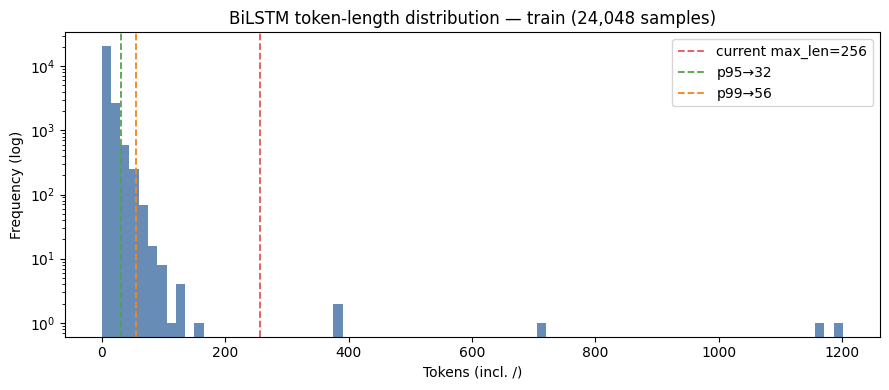


✓ saved → d:\Graduation Project\results\figures\dl_length_distribution.png


In [19]:
# E1.3 — Truncation analysis at current max_len + histogram + max_len recommendation.
import matplotlib.pyplot as plt

MAX_LEN_CURRENT = DEEP_LEARNING_CONFIG["max_len"]
trunc_mask = raw_lengths > MAX_LEN_CURRENT
trunc_pct  = 100 * trunc_mask.mean()

print(f"Truncation at current max_len = {MAX_LEN_CURRENT}:")
print(f"  truncated samples: {int(trunc_mask.sum()):,} / {N:,}  ({trunc_pct:.2f}%)")

def _round_up(x, base=8):
    return int(np.ceil(x / base) * base)

rec_p95 = _round_up(stats_pct["p95"])
rec_p99 = _round_up(stats_pct["p99"])
print(f"\nRecommended max_len (rounded up to multiple of 8):")
print(f"  p95 → max_len = {rec_p95:<4d}  (truncates ~5% of train)")
print(f"  p99 → max_len = {rec_p99:<4d}  (truncates ~1% of train)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(raw_lengths, bins=80, color="#4C78A8", alpha=0.85)
for x, label, color in [
    (MAX_LEN_CURRENT, f"current max_len={MAX_LEN_CURRENT}", "#E45756"),
    (rec_p95,         f"p95→{rec_p95}",                     "#54A24B"),
    (rec_p99,         f"p99→{rec_p99}",                     "#F58518"),
]:
    ax.axvline(x, color=color, linestyle="--", linewidth=1.3, label=label)
ax.set_xlabel("Tokens (incl. /)")
ax.set_ylabel("Frequency (log)")
ax.set_yscale("log")
ax.set_title(f"BiLSTM token-length distribution — train ({N:,} samples)")
ax.legend()
plt.tight_layout()

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig_path = FIG_DIR / "dl_length_distribution.png"
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"\n✓ saved → {fig_path}")

# E2 — PhoBERT Memory Profile

Each config runs forward + backward + optimizer.step with the right `grad_accum`-many backward passes, on the real PhoBERT-v2 model and a real AdamW. We measure `torch.cuda.max_memory_allocated()` per config and catch OOMs gracefully.

**Safety ceiling for a 6 GB card with room for the validation pass is approximately 5.0 GB.**

In [22]:
# E2.1 — Profiling helper. Catches OOM both as torch.cuda.OutOfMemoryError
# and as legacy RuntimeError('CUDA out of memory ...') on older PyTorch.
import gc
from contextlib import nullcontext

def profile_phobert_config(model, optimizer, batch_size, max_len, fp16, grad_accum=1):
    """Run one (accumulated) training step. Returns (peak_gb, ok, err_msg)."""
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    optimizer.zero_grad(set_to_none=True)

    vocab_size = model.config.vocab_size
    try:
        for _ in range(grad_accum):
            dummy_input  = torch.randint(0, vocab_size, (batch_size, max_len), device="cuda")
            dummy_mask   = torch.ones(batch_size, max_len, dtype=torch.long, device="cuda")
            dummy_labels = torch.randint(0, 3, (batch_size,), device="cuda")

            amp_ctx = torch.cuda.amp.autocast(dtype=torch.float16) if fp16 else nullcontext()
            with amp_ctx:
                out  = model(input_ids=dummy_input, attention_mask=dummy_mask, labels=dummy_labels)
                loss = out.loss / grad_accum
            loss.backward()

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        peak = torch.cuda.max_memory_allocated() / 1e9
        return peak, True, None
    except torch.cuda.OutOfMemoryError as e:
        optimizer.zero_grad(set_to_none=True)
        torch.cuda.empty_cache(); gc.collect()
        return None, False, str(e).splitlines()[0][:120]
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            optimizer.zero_grad(set_to_none=True)
            torch.cuda.empty_cache(); gc.collect()
            return None, False, str(e).splitlines()[0][:120]
        raise

In [23]:
# E2.2 — Load PhoBERT + AdamW, profile 8 configs, print table, save JSON.
from transformers import AutoModelForSequenceClassification

PHOBERT_NAME = PHOBERT_CONFIG["pretrained_model"]
print(f"Loading model for profiling: {PHOBERT_NAME}")
with Timer("phobert-load"):
    profile_model = AutoModelForSequenceClassification.from_pretrained(
        PHOBERT_NAME, num_labels=3
    ).cuda()
profile_optim = torch.optim.AdamW(profile_model.parameters(), lr=2e-5, weight_decay=0.01)

# (batch_size, max_len, fp16, grad_accum, label)
configs = [
    (16, 256, False, 1, "current (no fp16)"),
    (16, 256, True,  1, "current + fp16"),
    ( 8, 256, True,  2, "bs=8 accum=2 (eff=16)"),
    ( 8, 128, True,  2, "bs=8 accum=2 len=128"),
    (16, 128, True,  1, "bs=16 len=128 fp16"),
    (16, 128, False, 1, "bs=16 len=128 no fp16"),
    ( 4, 256, True,  4, "bs=4 accum=4 (eff=16)"),
    (32, 128, True,  1, "bs=32 len=128 aggressive"),
]

VRAM_TOTAL = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"Total VRAM: {VRAM_TOTAL:.2f} GB | profiling {len(configs)} configs...\n")

memory_results = []
for bs, ml, fp16, accum, label in configs:
    with Timer(f"cfg {label}", silent=True) as t:
        peak, ok, err = profile_phobert_config(profile_model, profile_optim, bs, ml, fp16, accum)
    memory_results.append({
        "label": label, "batch_size": bs, "max_len": ml, "fp16": bool(fp16),
        "grad_accum": accum, "eff_batch": bs * accum,
        "peak_gb": peak,
        "vram_pct": (100 * peak / VRAM_TOTAL) if peak is not None else None,
        "ok": bool(ok), "err": err, "elapsed_s": t.elapsed,
    })

header = f"{'config':<26s} {'bs':>3s} {'len':>4s} {'fp16':>5s} {'acc':>4s} {'eff':>4s} {'peak':>8s} {'%vram':>6s}  status"
print(header)
print("-" * len(header))
for r in memory_results:
    if r["ok"]:
        peak_s, pct_s, status = f"{r['peak_gb']:.2f} GB", f"{r['vram_pct']:5.1f}%", "✓ ok"
    else:
        peak_s, pct_s, status = "  —   ", "  —  ", "✗ OOM"
    print(f"{r['label']:<26s} {r['batch_size']:>3d} {r['max_len']:>4d} "
          f"{str(r['fp16']):>5s} {r['grad_accum']:>4d} {r['eff_batch']:>4d} "
          f"{peak_s:>8s} {pct_s:>6s}  {status}")

ok_results = [r for r in memory_results if r["ok"]]
SAFE_CEIL  = 5.0
recommended = None
if ok_results:
    safe = [r for r in ok_results if r["peak_gb"] < SAFE_CEIL]
    recommended = (min(safe,        key=lambda r: r["peak_gb"]) if safe
                   else min(ok_results, key=lambda r: r["peak_gb"]))
    max_thru   = max(ok_results, key=lambda r: r["eff_batch"])
    print(f"\nRECOMMENDED (peak < {SAFE_CEIL} GB safety margin):")
    print(f"  {recommended['label']:<26s}  peak={recommended['peak_gb']:.2f} GB  eff_batch={recommended['eff_batch']}")
    print(f"MAX THROUGHPUT (largest eff_batch that fits):")
    print(f"  {max_thru['label']:<26s}  peak={max_thru['peak_gb']:.2f} GB  eff_batch={max_thru['eff_batch']}")
else:
    print("\n✗ Every config OOMed — try a smaller model or drop max_len below 128.")

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / "phobert_memory_profile.json", "w", encoding="utf-8") as f:
    json.dump({"vram_total_gb": VRAM_TOTAL,
               "configs": memory_results,
               "recommended": recommended}, f, indent=2)
print(f"\n✓ saved → {RESULTS_DIR / 'phobert_memory_profile.json'}")

del profile_model, profile_optim
gc.collect(); torch.cuda.empty_cache()
print("✓ profile model freed")

Loading model for profiling: vinai/phobert-base-v2


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[phobert-load] 0:01 (1.25s)
Total VRAM: 6.44 GB | profiling 8 configs...



C:\Users\Minh Duc\AppData\Local\Temp\ipykernel_3016\2185257174.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  amp_ctx = torch.cuda.amp.autocast(dtype=torch.float16) if fp16 else nullcontext()


config                      bs  len  fp16  acc  eff     peak  %vram  status
---------------------------------------------------------------------------
current (no fp16)           16  256 False    1   16  3.08 GB  47.8%  ✓ ok
current + fp16              16  256  True    1   16  3.47 GB  53.8%  ✓ ok
bs=8 accum=2 (eff=16)        8  256  True    2   16  3.28 GB  50.9%  ✓ ok
bs=8 accum=2 len=128         8  128  True    2   16  2.85 GB  44.2%  ✓ ok
bs=16 len=128 fp16          16  128  True    1   16  2.81 GB  43.6%  ✓ ok
bs=16 len=128 no fp16       16  128 False    1   16  2.96 GB  45.9%  ✓ ok
bs=4 accum=4 (eff=16)        4  256  True    4   16  2.85 GB  44.2%  ✓ ok
bs=32 len=128 aggressive    32  128  True    1   32  3.47 GB  53.8%  ✓ ok

RECOMMENDED (peak < 5.0 GB safety margin):
  bs=16 len=128 fp16          peak=2.81 GB  eff_batch=16
MAX THROUGHPUT (largest eff_batch that fits):
  bs=32 len=128 aggressive    peak=3.47 GB  eff_batch=32

✓ saved → d:\Graduation Project\results\phobert_mem

# E3 — Mini Smoke Training (10 BiLSTM + 5 PhoBERT Steps)
Catches the bugs that only show up once you push a real batch through a real model:
- NaN logits from a length=1 sample
- Exploding embedding grads
- FP16 underflow
- Optimizer-state OOM

In [27]:
# E3.1 — BiLSTM 10-step sanity training.
import torch.nn as nn

class TinyBiLSTM(nn.Module):
    def __init__(self, emb_matrix, num_classes=3, hidden=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(emb_matrix, padding_idx=0, freeze=False)
        d = emb_matrix.size(1)
        self.lstm    = nn.LSTM(d, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden * 2, num_classes)

    def forward(self, input_ids, lengths):
        emb = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h, _) = self.lstm(packed)
        return self.fc(self.dropout(torch.cat([h[0], h[1]], dim=-1)))

set_seed(RANDOM_STATE)
# C3 saved a dict {'embedding': tensor, 'stats': ..., 'choice': ...}; unwrap if needed.
_loaded    = torch.load(EMBEDDING_MATRIX_PATH, weights_only=True)
emb_tensor = _loaded["embedding"] if isinstance(_loaded, dict) else _loaded
lstm_model = TinyBiLSTM(emb_tensor).cuda()
lstm_optim = torch.optim.Adam(lstm_model.parameters(),
                              lr=DEEP_LEARNING_CONFIG["learning_rate"])
lstm_crit  = nn.CrossEntropyLoss(weight=class_weights.cuda())

torch.cuda.reset_peak_memory_stats()
lstm_losses, lstm_gnorms = [], []
lstm_model.train()
lstm_loader = DataLoader(
    train_ds_lstm, batch_size=DEEP_LEARNING_CONFIG["batch_size"],
    shuffle=True, collate_fn=collate_fn_bilstm,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)

with Timer("bilstm-10-steps"):
    for step, batch in enumerate(lstm_loader):
        if step >= 10:
            break
        input_ids = batch["input_ids"].cuda()
        lengths   = batch["lengths"]
        labels    = batch["labels"].cuda()

        logits = lstm_model(input_ids, lengths)
        loss   = lstm_crit(logits, labels)
        if torch.isnan(loss):
            raise RuntimeError(f"NaN loss at step {step} — investigate before training.")

        lstm_optim.zero_grad(set_to_none=True)
        loss.backward()
        gnorm = torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=5.0)
        lstm_optim.step()

        lstm_losses.append(float(loss))
        lstm_gnorms.append(float(gnorm))
        print(f"  step {step+1:>2d}/10  loss={float(loss):.4f}  gnorm={float(gnorm):.3f}")

bilstm_peak       = torch.cuda.max_memory_allocated() / 1e9
bilstm_no_nan     = not any(np.isnan(x) for x in lstm_losses)
bilstm_decreasing = lstm_losses[-1] < lstm_losses[0]
bilstm_grad_sane  = all(0.0 < g < 50.0 for g in lstm_gnorms)

print(f"\nBiLSTM sanity verdict:")
print(f"  no NaN          : {'✓' if bilstm_no_nan else '✗'}")
print(f"  loss decreasing : {'✓' if bilstm_decreasing else '✗'}  "
      f"({lstm_losses[0]:.4f} → {lstm_losses[-1]:.4f})")
print(f"  grad norm sane  : {'✓' if bilstm_grad_sane else '✗'}  "
      f"(range {min(lstm_gnorms):.2f} – {max(lstm_gnorms):.2f})")
print(f"  peak VRAM       : {bilstm_peak:.2f} GB")

del lstm_model, lstm_optim, lstm_crit
gc.collect(); torch.cuda.empty_cache()

  step  1/10  loss=1.1049  gnorm=0.184
  step  2/10  loss=1.0911  gnorm=0.191
  step  3/10  loss=1.0753  gnorm=0.367
  step  4/10  loss=1.1283  gnorm=0.359
  step  5/10  loss=1.0855  gnorm=0.138
  step  6/10  loss=1.0859  gnorm=0.194
  step  7/10  loss=1.1310  gnorm=0.337
  step  8/10  loss=1.0745  gnorm=0.150
  step  9/10  loss=1.1206  gnorm=0.300
  step 10/10  loss=1.1116  gnorm=0.258
[bilstm-10-steps] 0:00 (0.42s)

BiLSTM sanity verdict:
  no NaN          : ✓
  loss decreasing : ✗  (1.1049 → 1.1116)
  grad norm sane  : ✓  (range 0.14 – 0.37)
  peak VRAM       : 0.11 GB


In [28]:
# E3.2 — PhoBERT 5-step sanity training (uses recommended config from E2).
phobert_no_oom = True
phobert_no_nan = False
phobert_losses = []

if recommended is None:
    print("⚠ Skipping PhoBERT sanity training — no config fit in VRAM.")
else:
    rec_bs, rec_ml, rec_fp16, rec_accum = (
        recommended["batch_size"], recommended["max_len"],
        recommended["fp16"],       recommended["grad_accum"],
    )
    print(f"Using recommended config: bs={rec_bs} max_len={rec_ml} "
          f"fp16={rec_fp16} accum={rec_accum} (eff={rec_bs*rec_accum})")

    set_seed(RANDOM_STATE)

    bert_ds_short = ViHSDDataset(
        texts     = train_df["cleaned"].tolist(),
        labels    = train_df[LABEL].tolist(),
        tokenizer = phobert_tok,
        max_len   = rec_ml,
        mode      = "phobert",
    )
    bert_loader = DataLoader(
        bert_ds_short, batch_size=rec_bs, shuffle=True,
        collate_fn=collate_fn_phobert,
        generator=torch.Generator().manual_seed(RANDOM_STATE),
    )

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        PHOBERT_NAME, num_labels=3
    ).cuda()
    bert_optim = torch.optim.AdamW(bert_model.parameters(),
                                    lr=PHOBERT_CONFIG["learning_rate"],
                                    weight_decay=PHOBERT_CONFIG["weight_decay"])
    bert_crit  = nn.CrossEntropyLoss(weight=class_weights.cuda())
    scaler     = torch.cuda.amp.GradScaler() if rec_fp16 else None

    torch.cuda.reset_peak_memory_stats()
    bert_model.train()

    try:
        with Timer("phobert-5-steps"):
            it = iter(bert_loader)
            for step in range(5):
                bert_optim.zero_grad(set_to_none=True)
                step_loss = 0.0
                for _ in range(rec_accum):
                    batch     = next(it)
                    input_ids = batch["input_ids"].cuda()
                    attn      = batch["attention_mask"].cuda()
                    labels    = batch["labels"].cuda()
                    amp_ctx   = torch.cuda.amp.autocast(dtype=torch.float16) if rec_fp16 else nullcontext()
                    with amp_ctx:
                        out  = bert_model(input_ids=input_ids, attention_mask=attn)
                        loss = bert_crit(out.logits, labels) / rec_accum
                    if scaler is not None:
                        scaler.scale(loss).backward()
                    else:
                        loss.backward()
                    step_loss += float(loss) * rec_accum
                if scaler is not None:
                    scaler.step(bert_optim); scaler.update()
                else:
                    bert_optim.step()
                phobert_losses.append(step_loss / rec_accum)
                print(f"  step {step+1}/5  loss={phobert_losses[-1]:.4f}")
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        if "out of memory" in str(e).lower():
            phobert_no_oom = False
            print(f"  ✗ OOM mid-training: {str(e).splitlines()[0]}")
        else:
            raise

    phobert_peak   = torch.cuda.max_memory_allocated() / 1e9
    phobert_no_nan = bool(phobert_losses) and not any(np.isnan(x) for x in phobert_losses)
    print(f"\nPhoBERT sanity verdict:")
    print(f"  no OOM    : {'✓' if phobert_no_oom else '✗'}")
    print(f"  no NaN    : {'✓' if phobert_no_nan else '✗'}")
    if phobert_losses:
        print(f"  losses    : {[round(x, 4) for x in phobert_losses]}")
    print(f"  peak VRAM : {phobert_peak:.2f} GB  (E2 prediction: {recommended['peak_gb']:.2f} GB)")

    del bert_model, bert_optim, bert_crit, bert_loader, bert_ds_short
    if scaler is not None:
        del scaler
    gc.collect(); torch.cuda.empty_cache()

Using recommended config: bs=16 max_len=128 fp16=True accum=1 (eff=16)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\Minh Duc\AppData\Local\Temp\ipykernel_3016\4259706778.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` ins

  step 1/5  loss=1.1103
  step 2/5  loss=1.0910
  step 3/5  loss=1.1332
  step 4/5  loss=1.1247
  step 5/5  loss=1.1320
[phobert-5-steps] 0:01 (0.74s)

PhoBERT sanity verdict:
  no OOM    : ✓
  no NaN    : ✓
  losses    : [1.1103, 1.091, 1.1332, 1.1247, 1.132]
  peak VRAM : 2.80 GB  (E2 prediction: 2.81 GB)


In [29]:
# E4 — Aggregate verdict, save JSON, print suggested edits to configs/config.py.
verdict = {
    "length_stats": stats_pct,
    "short_samples": {
        "pct_len_eq_1":  float((raw_lengths == 1).mean() * 100),
        "pct_len_le_2":  float((raw_lengths <= 2).mean() * 100),
        "pct_len_le_5":  float((raw_lengths <= 5).mean() * 100),
    },
    "truncation": {
        "current_max_len": MAX_LEN_CURRENT,
        "pct_truncated":   float(trunc_pct),
        "p95_recommended": rec_p95,
        "p99_recommended": rec_p99,
    },
    "memory_profile":      memory_results,
    "recommended_phobert": recommended,
    "sanity": {
        "bilstm_no_nan":     bool(bilstm_no_nan),
        "bilstm_decreasing": bool(bilstm_decreasing),
        "bilstm_grad_sane":  bool(bilstm_grad_sane),
        "bilstm_losses":     [float(x) for x in lstm_losses],
        "phobert_no_oom":    bool(phobert_no_oom),
        "phobert_no_nan":    bool(phobert_no_nan),
        "phobert_losses":    [float(x) for x in phobert_losses],
    },
}

OUT = ROOT / "results" / "dl_setup_verification.json"
with open(OUT, "w", encoding="utf-8") as f:
    json.dump(verdict, f, indent=2)
print(f"✓ saved → {OUT}\n")

print("══ DECISION SUMMARY ══════════════════════════════════════════════════")
pct_short = verdict["short_samples"]["pct_len_le_2"]
print(f"\nLength analysis:")
short_tag = "(SAFE)" if pct_short < 1 else "(WARN)" if pct_short < 5 else "(CRITICAL)"
print(f"  short samples (≤2 tokens) : {pct_short:5.2f}%  {short_tag}")
print(f"  truncation at max_len={MAX_LEN_CURRENT}    : {trunc_pct:5.2f}%")
if trunc_pct < 1:
    print(f"  → keep max_len={MAX_LEN_CURRENT}  (or shrink to p95={rec_p95} to save memory/time)")
else:
    print(f"  → consider max_len={rec_p95} (p95) or {rec_p99} (p99)")

if recommended:
    print(f"\nPhoBERT config for 6 GB:")
    print(f"  batch_size                : {recommended['batch_size']}")
    print(f"  max_len                   : {recommended['max_len']}")
    print(f"  fp16                      : {recommended['fp16']}")
    print(f"  gradient_accumulation     : {recommended['grad_accum']}   "
          f"(effective_batch={recommended['eff_batch']})")
    print(f"  peak_memory               : {recommended['peak_gb']:.2f} GB")
else:
    print("\nPhoBERT config: NONE FIT in 6 GB — need smaller model or shorter max_len.")

print(f"\nSanity training:")
print(f"  BiLSTM 10 steps  : {'✓ PASS' if (bilstm_no_nan and bilstm_grad_sane) else '✗ FAIL'}")
print(f"  PhoBERT 5 steps  : {'✓ PASS' if (phobert_no_oom and phobert_no_nan) else '✗ FAIL'}")

print(f"\nSuggested edits to configs/config.py before 04b/04c:")
edits = []
if trunc_pct >= 1:
    edits.append(f"  DEEP_LEARNING_CONFIG['max_len']      = {rec_p95}   # was {MAX_LEN_CURRENT}, p95 of train lengths")
if recommended:
    if recommended["max_len"] != PHOBERT_CONFIG["max_len"]:
        edits.append(f"  PHOBERT_CONFIG['max_len']            = {recommended['max_len']}   # was {PHOBERT_CONFIG['max_len']}")
    if recommended["batch_size"] != PHOBERT_CONFIG["batch_size"]:
        edits.append(f"  PHOBERT_CONFIG['batch_size']         = {recommended['batch_size']}    # was {PHOBERT_CONFIG['batch_size']}")
    if recommended["fp16"]:
        edits.append(f"  PHOBERT_CONFIG['fp16']               = True  # NEW key — enable AMP")
    if recommended["grad_accum"] > 1:
        edits.append(f"  PHOBERT_CONFIG['grad_accum']         = {recommended['grad_accum']}    # NEW key — gradient accumulation")
if edits:
    print("\n".join(edits))
else:
    print("  (no changes needed — current configs are already optimal)")

✓ saved → d:\Graduation Project\results\dl_setup_verification.json

══ DECISION SUMMARY ══════════════════════════════════════════════════

Length analysis:
  short samples (≤2 tokens) : 11.02%  (CRITICAL)
  truncation at max_len=256    :  0.02%
  → keep max_len=256  (or shrink to p95=32 to save memory/time)

PhoBERT config for 6 GB:
  batch_size                : 16
  max_len                   : 128
  fp16                      : True
  gradient_accumulation     : 1   (effective_batch=16)
  peak_memory               : 2.81 GB

Sanity training:
  BiLSTM 10 steps  : ✓ PASS
  PhoBERT 5 steps  : ✓ PASS

Suggested edits to configs/config.py before 04b/04c:
  PHOBERT_CONFIG['max_len']            = 128   # was 256
  PHOBERT_CONFIG['fp16']               = True  # NEW key — enable AMP


## Summary — what we have, what's next

Saved under `models/`:

* `models/dl/vocab.pkl`                            — word vocabulary (≤ 20 k)
* `models/dl/embedding_matrix_<choice>.pt`         — pretrained embedding matrix
* `models/dl/class_weights.pt`                     — `[w_clean, w_offensive, w_hate]`
* `models/embeddings/<file>`                       — raw download (git-ignored)

**Next (Prompt 2):** `notebooks/04b_bilstm.ipynb` — define and train a
BiLSTM-attention model on top of the saved embedding matrix; target
> baseline ML champion (F1_macro_test = 0.6183).